In [1]:
!pip install kagglehub
!pip install pandas numpy scikit-learn matplotlib seaborn

Importing Libraries

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
import pickle

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

Importing Datasets

In [3]:
path = kagglehub.dataset_download("mohamedasem318/wesad-full-dataset")

print("Dataset 1 path:", path)
os.listdir(path)

Using Colab cache for faster access to the 'wesad-full-dataset' dataset.
Dataset 1 path: /kaggle/input/wesad-full-dataset


['README.txt', 'LICENSE.txt', 'WESAD']

In [4]:
pkl_files = []

for root, dirs, files1 in os.walk(path):
    for file in files1:
        if file.endswith(".pkl"):
            pkl_files.append(os.path.join(root,file))

In [5]:
all_data = []

for file in pkl_files:

    with open(file,'rb') as f:
        data = pickle.load(f,encoding='latin1')

    chest = data['signal']['chest']

    df = pd.DataFrame({
        "acc_x": chest['ACC'][:,0],
        "acc_y": chest['ACC'][:,1],
        "acc_z": chest['ACC'][:,2],
        "eda": chest['EDA'].flatten(),
        "temp": chest['Temp'].flatten(),
        "resp": chest['Resp'].flatten(),
        "label": data['label'].flatten()
    })

    all_data.append(df)

dataset1 = pd.concat(all_data,ignore_index=True)

dataset1.head()

,acc_x,acc_y,acc_z,eda,temp,resp,label
0,0.7654,-0.1888,0.3714,2.738953,32.824799,-1.330566,0
1,0.7160,-0.2296,0.3950,2.727127,32.824799,-1.316833,0
2,0.6840,-0.2580,0.3934,2.740097,32.809814,-1.292419,0
3,0.6648,-0.2792,0.3672,2.739334,32.776855,-1.271057,0
4,0.6562,-0.2898,0.3262,2.729034,32.823303,-1.258850,0


In [39]:
uploaded = files.upload()

Saving file1.csv to file1 (4).csv
Saving file2.csv to file2 (4).csv
Saving file3.csv to file3 (4).csv


In [40]:
dataset2_a = pd.read_csv("file1.csv")
dataset2_b = pd.read_csv("file2.csv")
dataset2_c = pd.read_csv("file3.csv")

dataset2 = pd.concat([dataset2_a,dataset2_b,dataset2_c],ignore_index=True)
print(dataset2.shape)

(20000, 15)


In [8]:
uploaded = files.upload()

dataset3 = pd.read_csv("dataset3.csv")

Saving dataset3.csv to dataset3 (3).csv


In [52]:
target = "label"

In [53]:
dataset1 = dataset1.select_dtypes(include=['number'])
dataset2 = dataset2.select_dtypes(include=['number'])
dataset3 = dataset3.select_dtypes(include=['number'])

In [54]:
dataset1["source"] = 1
dataset2["source"] = 2
dataset3["source"] = 3

In [55]:
combined_dataset = pd.concat(
    [dataset1, dataset2, dataset3],
    ignore_index=True
)

In [56]:
combined_dataset = combined_dataset.fillna(0)

In [57]:
print(combined_dataset.shape)

(25388, 29)


Model Training Function

In [58]:
def train_model(data):

    data = data.dropna()

    X = data.drop(target,axis=1)
    y = data[target]

    X_train,X_test,y_train,y_test = train_test_split(
        X,y,test_size=0.2,random_state=42
    )

    model = RandomForestClassifier()

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    return accuracy_score(y_test,pred)


Combine all datasets

In [59]:
dataset1 = dataset1.sample(min(5000, len(dataset1)))
dataset2 = dataset2.sample(min(5000, len(dataset2)))
dataset3 = dataset3.sample(min(5000, len(dataset3)))

In [60]:
combined_dataset = pd.concat(
    [dataset1,dataset2,dataset3],
    ignore_index=True
)

Train on combined dataset

Create on Training function

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def train_model(data):

    X = data.drop(target, axis=1)
    y = data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier()

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    return acc

In [62]:
dataset1 = dataset1.fillna(0)
dataset2 = dataset2.fillna(0)
dataset3 = dataset3.fillna(0)
combined_dataset = combined_dataset.fillna(0)

In [63]:
print("Dataset1:", dataset1.shape)
print("Dataset2:", dataset2.shape)
print("Dataset3:", dataset3.shape)
print("Combined:", combined_dataset.shape)

Dataset1: (5000, 8)
Dataset2: (5000, 15)
Dataset3: (388, 12)
Combined: (10388, 29)


In [68]:
dataset2["label"] = 0
dataset3["label"] = 1

In [69]:
acc1 = train_model(dataset1)
acc2 = train_model(dataset2)
acc3 = train_model(dataset3)

print("Dataset 1 Accuracy:", acc1)
print("Dataset 2 Accuracy:", acc2)
print("Dataset 3 Accuracy:", acc3)

Dataset 1 Accuracy: 0.877
Dataset 2 Accuracy: 1.0
Dataset 3 Accuracy: 1.0


In [70]:
combined_accuracy = train_model(combined_dataset)

print("Combined Dataset Accuracy:", combined_accuracy)

Combined Dataset Accuracy: 0.9350336862367661


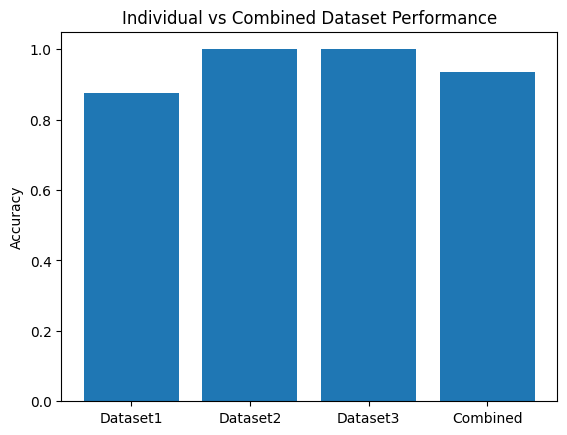

In [71]:
labels = ["Dataset1","Dataset2","Dataset3","Combined"]
accuracies = [acc1,acc2,acc3,combined_accuracy]

plt.bar(labels,accuracies)

plt.title("Individual vs Combined Dataset Performance")
plt.ylabel("Accuracy")

plt.show()

ALL OTHER MODELS

In [74]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


def train_classical_models(df):

    X = df.drop("label", axis=1)
    y = df["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {

        "Logistic": LogisticRegression(),
        "RF": RandomForestClassifier(),
        "XGBoost": XGBClassifier()
    }

    results = {}

    for name, model in models.items():

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        prob = model.predict_proba(X_test)[:,1]

        acc = accuracy_score(y_test, preds)

        auc = roc_auc_score(y_test, prob)

        results[name] = (acc, auc)

    return results

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def train_all_models(df):

    X = df.drop("label", axis=1)
    y = df["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {

        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("logistic", LogisticRegression(max_iter=5000))
        ]),

        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

        "XGBoost": XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            eval_metric="mlogloss"
        )
    }

    results = {}
    trained_models = {}

    for name, model in models.items():

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        prob = model.predict_proba(X_test)

        acc = accuracy_score(y_test, preds)

        auc = roc_auc_score(y_test, prob, multi_class="ovr")

        results[name] = (acc, auc)

        trained_models[name] = model

    return results, trained_models, X_train, X_test, y_train, y_test

In [91]:
results, models, X_train, X_test, y_train, y_test = train_all_models(combined_dataset)

print(results)

{'Logistic Regression': (0.762752646775746, np.float64(0.8660485424827917)), 'Random Forest': (0.9364773820981713, np.float64(0.9832250609943591)), 'XGBoost': (0.9355149181905679, np.float64(0.9876289986793175))}


Compare performance

Model Accuracy Comparison

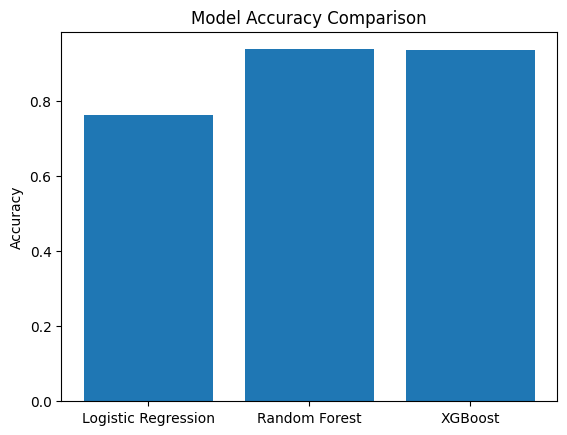

In [92]:
import matplotlib.pyplot as plt

models_list = list(results.keys())

accuracy = [results[m][0] for m in models_list]

plt.bar(models_list, accuracy)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

Confusion Matrix using the Best Model

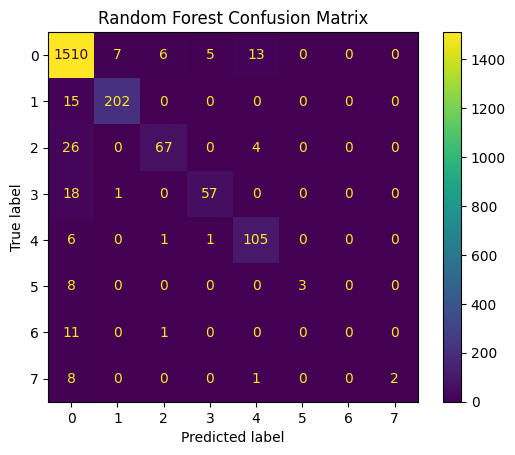

In [93]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_model = models["Random Forest"]

preds = rf_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

MULTICLASS ROC CURVE

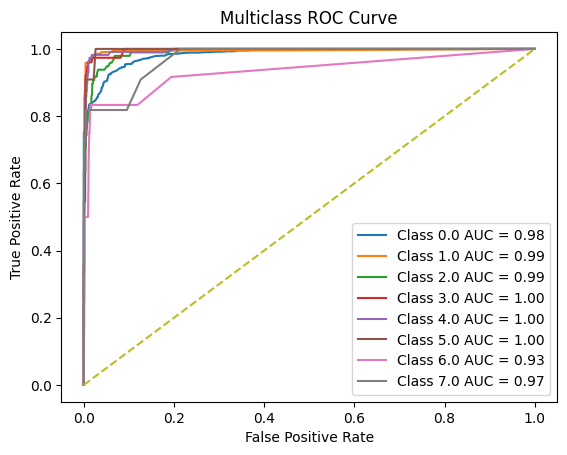

In [98]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

rf_model = models["Random Forest"]

y_score = rf_model.predict_proba(X_test)

classes = sorted(y_test.unique())

y_test_bin = label_binarize(y_test, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {classes[i]} AUC = {roc_auc:.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC Curve")

plt.legend()

plt.show()

In [99]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_score, multi_class="ovr")

print("Overall AUC:", auc_score)

Overall AUC: 0.9832250609943591


FEATURE ENGINEERING- Temporal Stress Drift Metrics

In [72]:
import numpy as np
import pandas as pd

class TSDM:

    def __init__(self):
        pass

    def stress_drift_index(self, series):

        drift = np.diff(series)

        sdi = np.mean(np.abs(drift))

        return sdi


    def cumulative_drift(self, series):

        drift = np.diff(series)

        cumulative = np.sum(drift)

        return cumulative


    def fatigue_state_vector(self, df):

        vector = []

        for col in df.columns:

            series = df[col].values

            sdi = self.stress_drift_index(series)

            cum = self.cumulative_drift(series)

            vector.append([sdi, cum])

        return np.array(vector)


    def transform(self, df):

        features = {}

        for col in df.columns:

            sdi = self.stress_drift_index(df[col])
            cum = self.cumulative_drift(df[col])

            features[f"{col}_sdi"] = sdi
            features[f"{col}_cumdrift"] = cum

        return pd.DataFrame([features])

Stress-Aware LSTM for Overtraining Prediction

In [73]:
import torch
import torch.nn as nn


class SALSTM(nn.Module):

    def __init__(self, input_size, hidden_size=64, num_layers=2):

        super(SALSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.attention = nn.Linear(hidden_size, 1)

        self.fc = nn.Linear(hidden_size, 1)

        self.sigmoid = nn.Sigmoid()


    def forward(self, x):

        lstm_out, _ = self.lstm(x)

        attn_weights = torch.softmax(
            self.attention(lstm_out),
            dim=1
        )

        context = torch.sum(attn_weights * lstm_out, dim=1)

        output = self.fc(context)

        return self.sigmoid(output)